# Rayleigh-Bénard convection in a porous semicircle

$$
\mathbb{S}
\begin{cases}
\mathcal{L} = \mathcal{L}_\Omega & \text{scaling with semicircle radius and convective speed} \\
\mathcal{U} = K_{\text{ref}}\,g\Delta\rho/\mu_{\text{ref}} \\
\mathcal{T} = \phi_{\text{ref}}\mathcal{L}/\mathcal{U} \\
\Omega = \Omega = \{(x, y)~:~0 < x^2 + y^2 < 1^2~,~y>0\} \\
\partial\Omega_{\text{arc}} = \{(x, y)~:~ x^2 + y^2 = 1^2 \} \\
\partial\Omega_{\text{lower}} = \{(x, y)~:~ y=0 \} \\
\textbf{e}_g=-\textbf{e}_y & \text{vertically downward gravity} \\ 
\phi = 1 & \text{constitutive relations} \\
\mathsf{D} = \mathsf{I} \\ 
\mathsf{K} = \mathsf{I}\\ 
\mu = 1 \\
\rho(c) = -c \\
c_0(x,y)=\mathcal{N}(x,y) & \text{initial noise} \\
c_{\text{D}}\vert_{\partial\Omega_{\text{lower}}}=1 & \text{prescribed temperature on lower and arc boundaries} \\
c_{\text{D}}\vert_{\partial\Omega_{\text{arc}}}=0 \\
\psi_{\text{D}}\vert_{\partial\Omega}=0 & \text{no-penetration on entire boundary}
\end{cases}
$$

In [1]:
from lucifex.fdm import AB2, CN
from lucifex.sim import run
from lucifex.utils import triangulation, as_indices
from lucifex.viz import plot_colormap, plot_mesh, save_figure, create_animation, display_animation
from py.C01_darcy_rayleigh_benard import darcy_rayleigh_benard_semicircle

simulation = darcy_rayleigh_benard_semicircle(
    Nradial=32,
    scaling='advective',
    Ra=300.0, 
    c_eps=1e-3,  
    c_freq=8, 
    D_adv=AB2,
    D_diff=CN,
)

n_stop = 600
dt_init = 1e-6
n_init = 5
run(simulation, n_stop=n_stop, dt_init=dt_init, n_init=n_init)

c = simulation['c']

INFO:root:running build_ext
INFO:root:building 'libffcx_forms_8d15a5e39759208c5c55f8bb39565a36292a7a43' extension
INFO:root:clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -I/Users/George/miniconda3/envs/lucifex/lib/python3.10/site-packages/ffcx/codegeneration -I/Users/George/miniconda3/envs/lucifex/include/python3.10 -c libffcx_forms_8d15a5e39759208c5c55f8bb39565a36292a7a43.c -o ./libffcx_forms_8d15a5e39759208c5c55f8bb39565a36292a7a43.o -O2 -g0
INFO:root:clang -bundle -undefined dynamic_lookup -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib ./libffcx_forms_8d15a5e39759208c5c55f8bb39565a36292a7a43.o -o ./libffcx_forms_8d15a5e39759208c5c55f8bb39565a36292a7a43.cpython-310-darwin.

In [2]:
time_slice = slice(0, None, 4)
titles = [f'${c.name}(t={t:.3f})$' for t in c.time_series[time_slice]]

anim = create_animation(
    plot_colormap,
    colorbar=False,
)(c.series[time_slice], title=titles)
anim_path = save_figure(f'{c.name}(t)', get_path=True)(anim)

display_animation(anim_path)

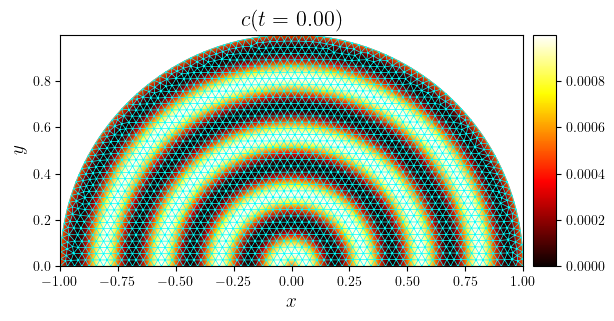

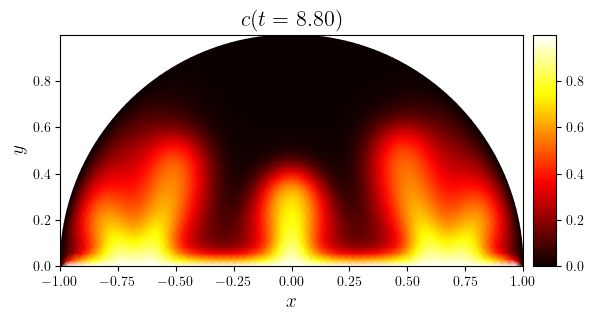

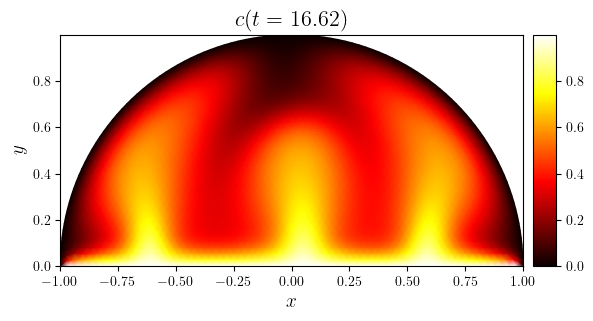

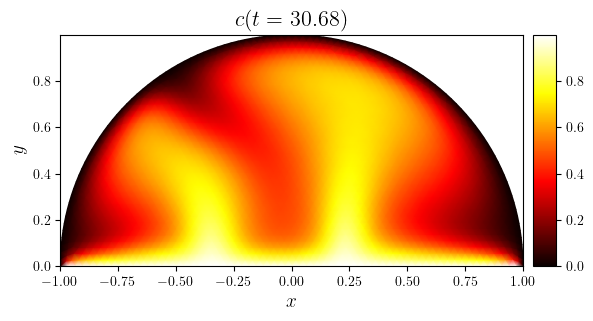

In [3]:
mesh = c.mesh
mesh_tri = triangulation(c.function_space.mesh)
x, y = mesh_tri.x, mesh_tri.y

time_indices = as_indices(c.time_series, (0, 0.25, 0.5, -1), fraction=True)
for i in time_indices:
    c_tri = triangulation(c.series[i])
    fig, ax = plot_colormap(
        (mesh_tri, c_tri), 
        title=f'${c.name}(t={c.time_series[i]:.2f})$',
        cartesian=False, 
    )
    if i == 0:
        plot_mesh(fig, ax, mesh, color='cyan', linewidth=0.5)
    save_figure(f'{c.name}(t={c.time_series[i]:.2f})', thumbnail=(i == -1))(fig)